# ML4SCI Common Task 1: Quark/Gluon Autoencoder with EDA

This notebook is a complete solution for **Common Task 1**:
- Explore the HDF5 jet dataset (EDA phase).
- Train a convolutional autoencoder on the 3-channel jet images.
- Show side-by-side original vs reconstructed events.

Dataset file: `quark-gluon_data-set_n139306.hdf5`

Expected datasets inside the file:
- `X_jets`: `(N, 125, 125, 3)`
- `m0`: `(N,)`
- `pt`: `(N,)`
- `y`: `(N,)` where 0=quark, 1=gluon

In [11]:
# Imports and global config
import os
import random
from pathlib import Path

import h5py
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from tqdm.auto import tqdm

CONFIG = {
    "data_path": "quark-gluon_data-set_n139306.hdf5",
    "seed": 42,
    "max_events": 50000,   # default CPU-safe cap, overridden below for CUDA
    "val_frac": 0.10,
    "test_frac": 0.10,
    "batch_size": 128,
    "num_workers": 0,
    "latent_dim": 128,
    "epochs": 12,
    "lr": 1e-3,
    "weight_decay": 1e-5,
    "norm_percentile": 99.9,
    "norm_sample_size": 800
}

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(CONFIG["seed"])

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Auto-apply runtime profile depending on available hardware.
if device.type == "cuda":
    vram_gb = torch.cuda.get_device_properties(0).total_memory / (1024 ** 3)
    CONFIG.update({
        "max_events": None,          # use full dataset on GPU by default
        "batch_size": 256,
        "num_workers": 4,
        "epochs": 16
    })
    # Keep settings conservative on smaller GPUs.
    if vram_gb < 8:
        CONFIG["batch_size"] = 64
        CONFIG["num_workers"] = 2
    elif vram_gb < 12:
        CONFIG["batch_size"] = 128
        CONFIG["num_workers"] = 2

    print("Using device:", device)
    print("CUDA device:", torch.cuda.get_device_name(0))
    print(f"CUDA memory: {vram_gb:.2f} GB")
else:
    CONFIG.update({
        "max_events": 50000,
        "batch_size": 128,
        "num_workers": 0,
        "epochs": 12
    })
    print("Using device:", device)

print("PyTorch version:", torch.__version__)
print("Active training config:", {
    "max_events": CONFIG["max_events"],
    "batch_size": CONFIG["batch_size"],
    "num_workers": CONFIG["num_workers"],
    "epochs": CONFIG["epochs"]
})

data_path = Path(CONFIG["data_path"])
if not data_path.exists():
    raise FileNotFoundError(f"Dataset not found at {data_path.resolve()}")

print("Dataset path:", data_path.resolve())
print("Dataset size (MB):", round(data_path.stat().st_size / 1024 / 1024, 2))

Using device: cpu
PyTorch version: 2.11.0+cpu
Active training config: {'max_events': 50000, 'batch_size': 128, 'num_workers': 0, 'epochs': 12}
Dataset path: /mnt/data/Documents/py/projects/ML4SCI/quark-gluon_data-set_n139306.hdf5
Dataset size (MB): 668.91


In [2]:
# 1) HDF5 schema inspection
with h5py.File(data_path, "r") as f:
    print("Top-level keys:", list(f.keys()))
    print()
    dataset_names = []

    def visitor(name, obj):
        if isinstance(obj, h5py.Dataset):
            dataset_names.append(name)
            print(f"Dataset: {name} | shape={obj.shape} | dtype={obj.dtype}")

    f.visititems(visitor)

print("\nDiscovered datasets:", dataset_names)

Top-level keys: ['X_jets', 'm0', 'pt', 'y']

Dataset: X_jets | shape=(139306, 125, 125, 3) | dtype=float32
Dataset: m0 | shape=(139306,) | dtype=float32
Dataset: pt | shape=(139306,) | dtype=float32
Dataset: y | shape=(139306,) | dtype=float32

Discovered datasets: ['X_jets', 'm0', 'pt', 'y']


In [3]:
# 2) Load metadata arrays and summarize
with h5py.File(data_path, "r") as f:
    y_all = f["y"][:].astype(np.int64)
    m0_all = f["m0"][:].astype(np.float32)
    pt_all = f["pt"][:].astype(np.float32)
    x_shape = f["X_jets"].shape

n_events = x_shape[0]
h, w, c = x_shape[1], x_shape[2], x_shape[3]

print(f"X_jets shape: {x_shape}")
print(f"Number of events: {n_events}")
print(f"Image size: {h} x {w}, channels: {c}")

unique, counts = np.unique(y_all, return_counts=True)
class_count = dict(zip(unique.tolist(), counts.tolist()))
print("Class counts (0=quark, 1=gluon):", class_count)

print("m0 stats: min={:.4f}, max={:.4f}, mean={:.4f}, std={:.4f}".format(m0_all.min(), m0_all.max(), m0_all.mean(), m0_all.std()))
print("pt stats: min={:.4f}, max={:.4f}, mean={:.4f}, std={:.4f}".format(pt_all.min(), pt_all.max(), pt_all.mean(), pt_all.std()))

X_jets shape: (139306, 125, 125, 3)
Number of events: 139306
Image size: 125 x 125, channels: 3
Class counts (0=quark, 1=gluon): {0: 69653, 1: 69653}
m0 stats: min=3.3729, max=75.9505, mean=21.3922, std=6.4316
pt stats: min=70.1100, max=337.0517, mean=117.1239, std=26.0678


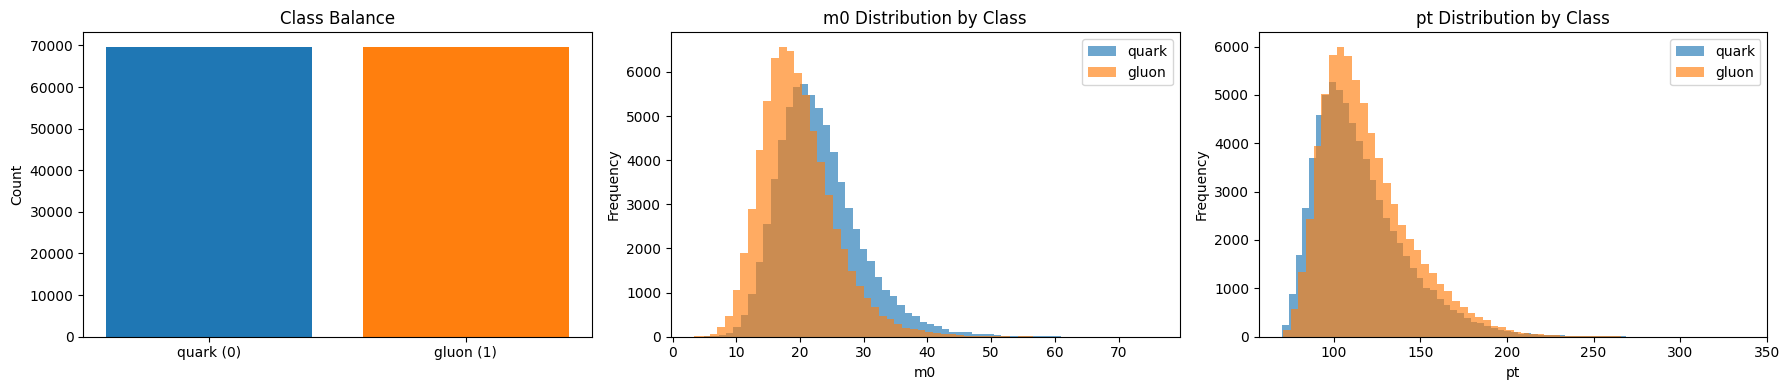

In [4]:
# 3) EDA plots: class balance, m0, pt
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# Class balance
labels = ["quark (0)", "gluon (1)"]
vals = [class_count.get(0, 0), class_count.get(1, 0)]
axes[0].bar(labels, vals, color=["tab:blue", "tab:orange"])
axes[0].set_title("Class Balance")
axes[0].set_ylabel("Count")

# m0 histogram by class
axes[1].hist(m0_all[y_all == 0], bins=60, alpha=0.65, label="quark", color="tab:blue")
axes[1].hist(m0_all[y_all == 1], bins=60, alpha=0.65, label="gluon", color="tab:orange")
axes[1].set_title("m0 Distribution by Class")
axes[1].set_xlabel("m0")
axes[1].set_ylabel("Frequency")
axes[1].legend()

# pt histogram by class
axes[2].hist(pt_all[y_all == 0], bins=60, alpha=0.65, label="quark", color="tab:blue")
axes[2].hist(pt_all[y_all == 1], bins=60, alpha=0.65, label="gluon", color="tab:orange")
axes[2].set_title("pt Distribution by Class")
axes[2].set_xlabel("pt")
axes[2].set_ylabel("Frequency")
axes[2].legend()

plt.tight_layout()
plt.show()

In [5]:
# 4) Channel-level sparsity and intensity statistics on a random subset
channel_names = ["ECAL", "HCAL", "Tracks"]
rng = np.random.default_rng(CONFIG["seed"])
sample_n = min(2500, n_events)
sample_indices = np.sort(rng.choice(n_events, size=sample_n, replace=False))

nonzero_counts = np.zeros(3, dtype=np.int64)
sum_intensity = np.zeros(3, dtype=np.float64)
max_intensity = np.zeros(3, dtype=np.float64)

with h5py.File(data_path, "r") as f:
    X = f["X_jets"]
    h, w, c = X.shape[1:]
    total_pixels = sample_n * h * w

    chunk_size = 128
    for start in tqdm(range(0, sample_n, chunk_size), desc="Computing channel stats"):
        idx_chunk = sample_indices[start:start + chunk_size]
        arr = X[idx_chunk]  # (B, 125, 125, 3)

        for ch in range(3):
            ch_arr = arr[..., ch]
            nonzero_counts[ch] += np.count_nonzero(ch_arr)
            sum_intensity[ch] += ch_arr.sum()
            max_intensity[ch] = max(max_intensity[ch], float(ch_arr.max()))

occupancy = nonzero_counts / total_pixels
mean_intensity_per_pixel = sum_intensity / total_pixels

for i, name in enumerate(channel_names):
    print(
        f"{name}: occupancy={occupancy[i]:.6f}, "
        f"mean_intensity_per_pixel={mean_intensity_per_pixel[i]:.8f}, "
        f"max_seen={max_intensity[i]:.6f}"
    )

Computing channel stats: 100%|██████████| 20/20 [02:04<00:00,  6.20s/it]

ECAL: occupancy=0.005007, mean_intensity_per_pixel=0.00007903, max_seen=6.172297
HCAL: occupancy=0.015722, mean_intensity_per_pixel=0.00005094, max_seen=1.313290
Tracks: occupancy=0.027019, mean_intensity_per_pixel=0.00003035, max_seen=0.069241


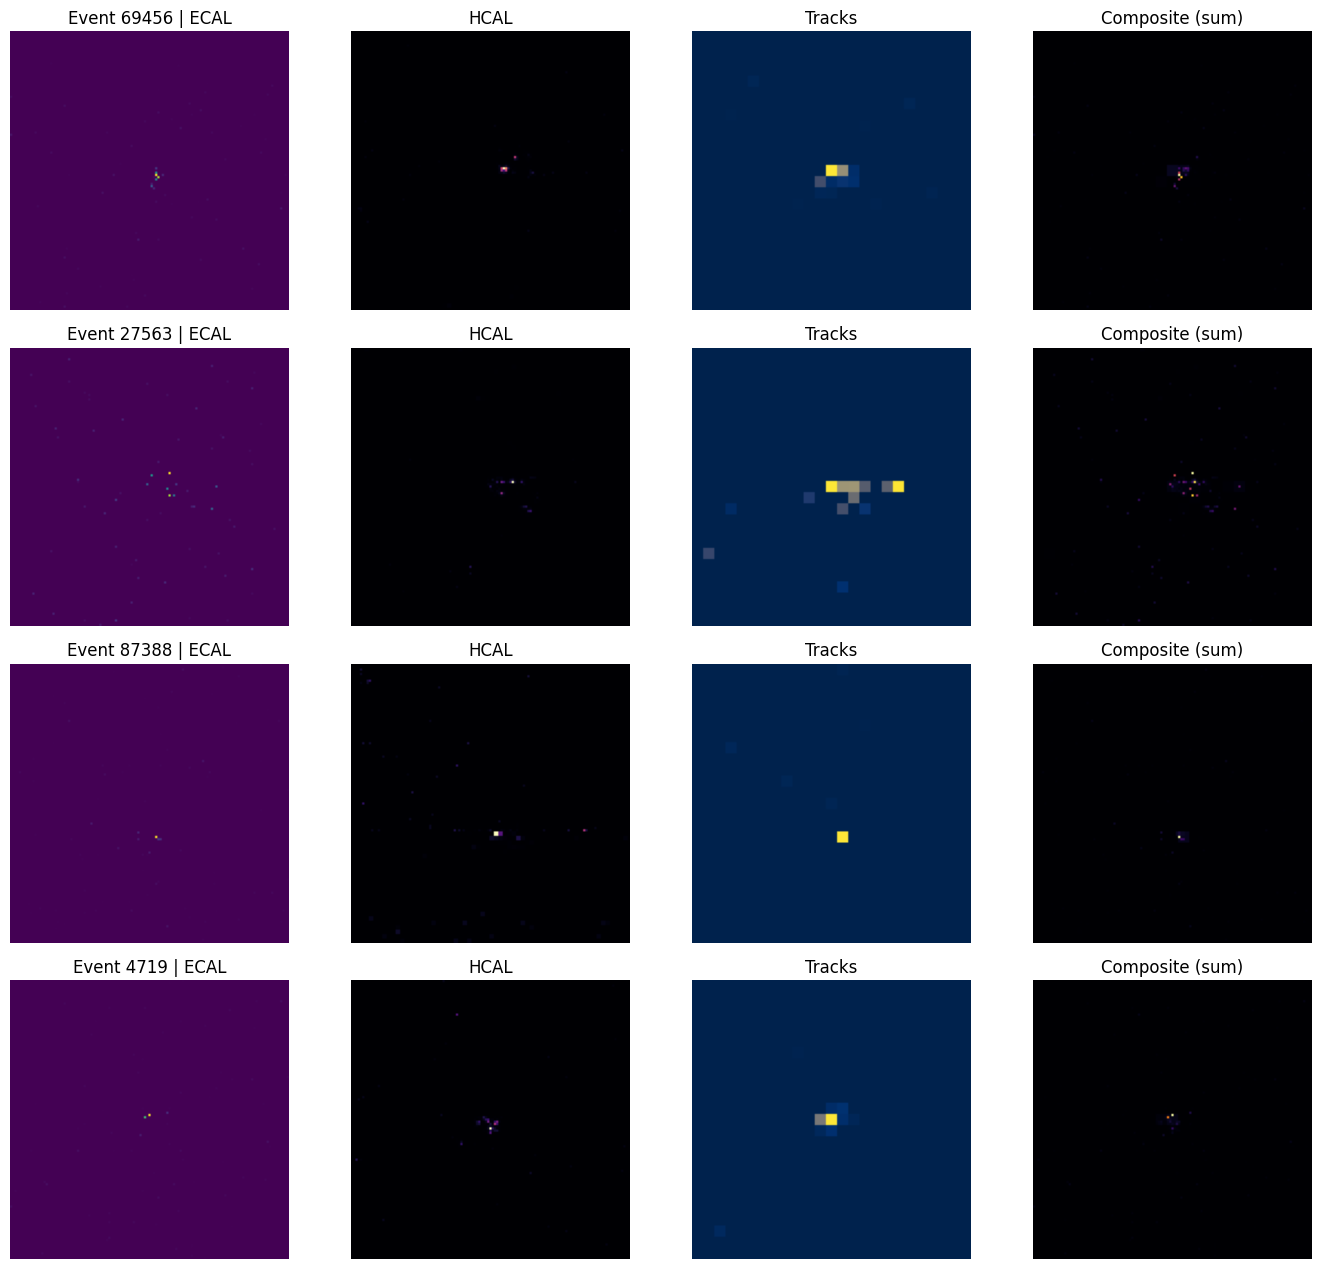

In [6]:
# 5) Visualize random events (per-channel + composite)
def normalize_img(img):
    img = img.astype(np.float32)
    m = img.max()
    if m > 0:
        img = img / m
    return img

n_show = 4
rand_indices = rng.choice(n_events, size=n_show, replace=False)

with h5py.File(data_path, "r") as f:
    X = f["X_jets"]
    fig, axes = plt.subplots(n_show, 4, figsize=(14, 3.2 * n_show))

    for r, idx in enumerate(rand_indices):
        event = X[idx]  # (125, 125, 3)
        ecal = normalize_img(event[..., 0])
        hcal = normalize_img(event[..., 1])
        trk = normalize_img(event[..., 2])
        comp = normalize_img(event.sum(axis=-1))

        axes[r, 0].imshow(ecal, cmap="viridis")
        axes[r, 0].set_title(f"Event {idx} | ECAL")
        axes[r, 1].imshow(hcal, cmap="magma")
        axes[r, 1].set_title("HCAL")
        axes[r, 2].imshow(trk, cmap="cividis")
        axes[r, 2].set_title("Tracks")
        axes[r, 3].imshow(comp, cmap="inferno")
        axes[r, 3].set_title("Composite (sum)")

        for cidx in range(4):
            axes[r, cidx].axis("off")

plt.tight_layout()
plt.show()

## Data Pipeline for Autoencoder

We do a stratified split by class label `y` so train/val/test remain balanced, then use an HDF5-backed PyTorch Dataset to avoid loading all images into RAM.

In [7]:
# 6) Stratified split indices (train/val/test)
def stratified_split_indices(y, val_frac=0.1, test_frac=0.1, max_events=None, seed=42):
    rng_local = np.random.default_rng(seed)
    y_int = y.astype(np.int64)
    classes = np.unique(y_int)

    train_idx, val_idx, test_idx = [], [], []

    for cls in classes:
        cls_idx = np.where(y_int == cls)[0]
        rng_local.shuffle(cls_idx)

        if max_events is not None:
            per_class_limit = max_events // len(classes)
            cls_idx = cls_idx[:per_class_limit]

        n = len(cls_idx)
        n_test = int(round(test_frac * n))
        n_val = int(round(val_frac * n))

        test_part = cls_idx[:n_test]
        val_part = cls_idx[n_test:n_test + n_val]
        train_part = cls_idx[n_test + n_val:]

        test_idx.extend(test_part.tolist())
        val_idx.extend(val_part.tolist())
        train_idx.extend(train_part.tolist())

    train_idx = np.array(train_idx, dtype=np.int64)
    val_idx = np.array(val_idx, dtype=np.int64)
    test_idx = np.array(test_idx, dtype=np.int64)

    rng_local.shuffle(train_idx)
    rng_local.shuffle(val_idx)
    rng_local.shuffle(test_idx)

    return train_idx, val_idx, test_idx

train_idx, val_idx, test_idx = stratified_split_indices(
    y_all,
    val_frac=CONFIG["val_frac"],
    test_frac=CONFIG["test_frac"],
    max_events=CONFIG["max_events"],
    seed=CONFIG["seed"]
)

print("Split sizes -> train:", len(train_idx), "val:", len(val_idx), "test:", len(test_idx))
print("Train class counts:", dict(zip(*np.unique(y_all[train_idx], return_counts=True))))
print("Val class counts:", dict(zip(*np.unique(y_all[val_idx], return_counts=True))))
print("Test class counts:", dict(zip(*np.unique(y_all[test_idx], return_counts=True))))

Split sizes -> train: 40000 val: 5000 test: 5000
Train class counts: {np.int64(0): np.int64(20000), np.int64(1): np.int64(20000)}
Val class counts: {np.int64(0): np.int64(2500), np.int64(1): np.int64(2500)}
Test class counts: {np.int64(0): np.int64(2500), np.int64(1): np.int64(2500)}


In [8]:
# 7) Estimate normalization scale from train subset
def estimate_scale(path, indices, sample_size=800, percentile=99.9, seed=42):
    rng_local = np.random.default_rng(seed)
    if len(indices) == 0:
        return 1.0

    k = min(sample_size, len(indices))
    pick = np.sort(rng_local.choice(indices, size=k, replace=False))

    with h5py.File(path, "r") as f:
        arr = f["X_jets"][pick]  # (k, 125, 125, 3)

    scale = float(np.percentile(arr, percentile))
    if not np.isfinite(scale) or scale <= 0:
        scale = float(arr.max())
    if not np.isfinite(scale) or scale <= 0:
        scale = 1.0
    return scale

norm_scale = estimate_scale(
    data_path,
    train_idx,
    sample_size=CONFIG["norm_sample_size"],
    percentile=CONFIG["norm_percentile"],
    seed=CONFIG["seed"]
)

print(f"Normalization scale (p{CONFIG['norm_percentile']}): {norm_scale:.6f}")

Normalization scale (p99.9): 0.009235


In [9]:
# 8) HDF5-backed Dataset + DataLoaders
class H5JetDataset(Dataset):
    def __init__(self, path, indices, scale=1.0):
        self.path = str(path)
        self.indices = np.asarray(indices, dtype=np.int64)
        self.scale = float(scale)
        self._file = None
        self._x = None

    def _ensure_open(self):
        if self._file is None:
            self._file = h5py.File(self.path, "r")
            self._x = self._file["X_jets"]

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        self._ensure_open()
        idx = int(self.indices[i])
        x = self._x[idx]  # (125,125,3)
        x = np.transpose(x, (2, 0, 1)).astype(np.float32)  # (3,125,125)
        x = np.clip(x / self.scale, 0.0, 1.0)
        x = torch.from_numpy(x)
        return x

    def __del__(self):
        try:
            if self._file is not None:
                self._file.close()
        except Exception:
            pass

train_ds = H5JetDataset(data_path, train_idx, scale=norm_scale)
val_ds = H5JetDataset(data_path, val_idx, scale=norm_scale)
test_ds = H5JetDataset(data_path, test_idx, scale=norm_scale)

pin_memory = device.type == "cuda"

train_loader = DataLoader(
    train_ds,
    batch_size=CONFIG["batch_size"],
    shuffle=True,
    num_workers=CONFIG["num_workers"],
    pin_memory=pin_memory
)

val_loader = DataLoader(
    val_ds,
    batch_size=CONFIG["batch_size"],
    shuffle=False,
    num_workers=CONFIG["num_workers"],
    pin_memory=pin_memory
)

test_loader = DataLoader(
    test_ds,
    batch_size=CONFIG["batch_size"],
    shuffle=False,
    num_workers=CONFIG["num_workers"],
    pin_memory=pin_memory
)

batch = next(iter(train_loader))
print("One batch shape:", batch.shape)

One batch shape: torch.Size([128, 3, 125, 125])


## Autoencoder Model

Input images are 125x125. The model temporarily pads to 128x128 for clean downsampling and then crops back to 125x125 at the output.

In [10]:
# 9) Convolutional autoencoder
class ConvAutoencoder(nn.Module):
    def __init__(self, latent_dim=128):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, stride=2, padding=1),   # 128 -> 64
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),  # 64 -> 32
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1), # 32 -> 16
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 256, kernel_size=3, stride=2, padding=1),# 16 -> 8
            nn.ReLU(inplace=True),
        )

        self.flatten_dim = 256 * 8 * 8
        self.to_latent = nn.Linear(self.flatten_dim, latent_dim)
        self.from_latent = nn.Linear(latent_dim, self.flatten_dim)

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1), # 8 -> 16
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),  # 16 -> 32
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),   # 32 -> 64
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(32, 16, kernel_size=4, stride=2, padding=1),   # 64 -> 128
            nn.ReLU(inplace=True),
            nn.Conv2d(16, 3, kernel_size=3, padding=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        # Pad 125x125 to 128x128
        x_pad = F.pad(x, (1, 2, 1, 2), mode="constant", value=0.0)

        h = self.encoder(x_pad)
        z = self.to_latent(h.flatten(1))
        h2 = self.from_latent(z).view(-1, 256, 8, 8)
        out_pad = self.decoder(h2)

        # Crop back to 125x125
        out = out_pad[:, :, 1:-2, 1:-2]
        return out

model = ConvAutoencoder(latent_dim=CONFIG["latent_dim"]).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=CONFIG["lr"], weight_decay=CONFIG["weight_decay"])

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {n_params:,}")

Trainable parameters: 5,296,227


In [ ]:
# Optional: faster verification profile for CPU runs
# This helps complete an end-to-end notebook run quickly on CPU.
if device.type == "cpu":
    CONFIG.update({
        "max_events": 10000,
        "batch_size": 64,
        "num_workers": 0,
        "epochs": 2
    })
    print("Applied CPU verification profile:", {
        "max_events": CONFIG["max_events"],
        "batch_size": CONFIG["batch_size"],
        "num_workers": CONFIG["num_workers"],
        "epochs": CONFIG["epochs"]
    })
else:
    print("CUDA detected, keeping current CONFIG for training.")

In [13]:
# 10) Training and validation loops
def run_epoch(model, loader, criterion, optimizer=None, device="cpu"):
    is_train = optimizer is not None
    model.train(is_train)

    total_loss = 0.0
    total_count = 0

    pbar = tqdm(loader, leave=False, desc="train" if is_train else "valid")
    for x in pbar:
        x = x.to(device, non_blocking=True)

        if is_train:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(is_train):
            x_hat = model(x)
            loss = criterion(x_hat, x)

            if is_train:
                loss.backward()
                optimizer.step()

        batch_size = x.size(0)
        total_loss += loss.item() * batch_size
        total_count += batch_size

        pbar.set_postfix(loss=f"{loss.item():.6f}")

    return total_loss / max(total_count, 1)

history = {"train_loss": [], "val_loss": []}

for epoch in range(1, CONFIG["epochs"] + 1):
    train_loss = run_epoch(model, train_loader, criterion, optimizer=optimizer, device=device)
    val_loss = run_epoch(model, val_loader, criterion, optimizer=None, device=device)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    print(f"Epoch {epoch:02d}/{CONFIG['epochs']} | train_loss={train_loss:.6f} | val_loss={val_loss:.6f}")

KeyboardInterrupt: 

In [ ]:
# 11) Training curves
plt.figure(figsize=(7, 4))
plt.plot(history["train_loss"], marker="o", label="Train")
plt.plot(history["val_loss"], marker="o", label="Validation")
plt.title("Autoencoder Loss (MSE)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# 12) Test reconstruction error
test_loss = run_epoch(model, test_loader, criterion, optimizer=None, device=device)
print(f"Test MSE: {test_loss:.6f}")

In [ ]:
# 13) Final requirement plot: side-by-side original vs reconstructed (8 events)
model.eval()

x_batch = next(iter(test_loader)).to(device)
with torch.no_grad():
    x_recon = model(x_batch)

x_batch = x_batch.cpu().numpy()
x_recon = x_recon.cpu().numpy()

def chw_to_hwc_rgb(x):
    # x: (3,125,125) in [0,1]
    img = np.transpose(x, (1, 2, 0))
    img = np.clip(img, 0.0, 1.0)
    m = img.max()
    if m > 0:
        img = img / m
    return img

n_show = 8
fig, axes = plt.subplots(n_show, 2, figsize=(8, 3 * n_show))

for i in range(n_show):
    orig = chw_to_hwc_rgb(x_batch[i])
    rec = chw_to_hwc_rgb(x_recon[i])

    axes[i, 0].imshow(orig)
    axes[i, 0].set_title(f"Original #{i+1}")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(rec)
    axes[i, 1].set_title(f"Reconstructed #{i+1}")
    axes[i, 1].axis("off")

plt.tight_layout()
plt.show()

In [12]:
# 14) Save and reload the trained model checkpoint
checkpoint_path = Path("autoencoder_task1.pt")

def save_checkpoint(model, optimizer, history, config, norm_scale, path):
    payload = {
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict() if optimizer is not None else None,
        "history": history,
        "config": config,
        "norm_scale": norm_scale
    }
    torch.save(payload, path)
    print(f"Checkpoint saved to: {path.resolve()}")

def load_checkpoint(path, device):
    ckpt = torch.load(path, map_location=device)
    loaded_model = ConvAutoencoder(latent_dim=ckpt["config"]["latent_dim"]).to(device)
    loaded_model.load_state_dict(ckpt["model_state_dict"])
    loaded_model.eval()

    loaded_optimizer = torch.optim.Adam(
        loaded_model.parameters(),
        lr=ckpt["config"].get("lr", 1e-3),
        weight_decay=ckpt["config"].get("weight_decay", 0.0)
    )
    if ckpt.get("optimizer_state_dict") is not None:
        loaded_optimizer.load_state_dict(ckpt["optimizer_state_dict"])

    return loaded_model, loaded_optimizer, ckpt

# Safe defaults if this cell is run before training cell.
history_for_ckpt = history if "history" in globals() else {"train_loss": [], "val_loss": []}
norm_scale_for_ckpt = norm_scale if "norm_scale" in globals() else None
optimizer_for_ckpt = optimizer if "optimizer" in globals() else None

save_checkpoint(model, optimizer_for_ckpt, history_for_ckpt, CONFIG, norm_scale_for_ckpt, checkpoint_path)

loaded_model, loaded_optimizer, loaded_ckpt = load_checkpoint(checkpoint_path, device)
print("Checkpoint keys:", list(loaded_ckpt.keys()))
print("Loaded model is ready for inference or continued training.")

Checkpoint saved to: /mnt/data/Documents/py/projects/ML4SCI/autoencoder_task1.pt
Checkpoint keys: ['model_state_dict', 'optimizer_state_dict', 'history', 'config', 'norm_scale']
Loaded model is ready for inference or continued training.


## Notes
- If training is slow on CPU, reduce `max_events` and/or `epochs`.
- If using GPU, keep `max_events` larger and increase `batch_size` when memory allows.
- You can save the trained model with `torch.save(model.state_dict(), 'autoencoder_task1.pt')`.